In [7]:
!pip install xgboost
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 45.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [shap]4/5 [shap]]te]


In [8]:
# ============================================================
# Claim Status Prediction: Paid vs Denied
# Nested CV + Multiple Models + SHAP
# ============================================================
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from xgboost import XGBClassifier
import shap
import matplotlib.pyplot as plt

In [9]:
# ============================================================
# 1. Load data
# ============================================================

DATA_DIR = Path("/Users/yuxi/python_assingment/cleaned data")

df = pd.read_csv(DATA_DIR / "FULLY MERGED.csv")


print("Loaded shape:", df.shape)
print(df.head())

Loaded shape: (441462, 42)
     claim_id appointment_id patient_id department_id  claim_amount  \
0  C000000002     A000129447   P0093567          D042       1023.43   
1  C000000003     A000204780   P0035732          D013        117.31   
2  C000000004     A000721527   P0012635          D003        549.19   
3  C000000005     A000364435   P0016099          D049        328.85   
4  C000000006     A000861687   P0086961          D036        610.06   

  insurance_type_at_claim  insurance_paid  patient_paid submission_date  \
0                 Private          582.39        441.04      2024-01-13   
1                Employer           66.76         50.55      2025-12-04   
2                  Public          322.62        226.57      2024-06-04   
3                  Public          289.36         39.49      2025-05-27   
4                  Public          374.81        235.25      2025-10-30   

  payment_date  ...  first_name last_name         dob  gender       region  \
0   2024-03-06  .

In [10]:
df.columns

Index(['claim_id', 'appointment_id', 'patient_id', 'department_id',
       'claim_amount', 'insurance_type_at_claim', 'insurance_paid',
       'patient_paid', 'submission_date', 'payment_date', 'claim_denied_final',
       'claim_status', 'amount_mismatch_flag', 'date_logic_flag',
       'patient_id_appt', 'provider_id', 'department_id_appt',
       'scheduled_date', 'appointment_date', 'visit_type', 'wait_days',
       'status', 'future_no_show_flag', 'patient_id_raw', 'status_raw',
       'department_name', 'location', 'annual_budget', 'base_wait_days',
       'manual_workload_multiplier', 'claim_denial_risk', 'lab_delay_risk',
       'first_name', 'last_name', 'dob', 'gender', 'region', 'postal_code',
       'insurance_type', 'chronic_diabetes', 'chronic_hypertension',
       'registration_date'],
      dtype='object')

In [11]:
# ============================================================
# 2. Basic target cleanup
# ============================================================

# Keep only Paid / Denied rows
df = df[df["claim_status"].isin(["Paid", "Denied"])].copy()

# Encode target: Denied = 1, Paid = 0
df["target_denied"] = (df["claim_status"] == "Denied").astype(int)

print(df["claim_status"].value_counts())
print(df["target_denied"].value_counts(normalize=True))

claim_status
Paid      365477
Denied     75985
Name: count, dtype: int64
target_denied
0    0.827879
1    0.172121
Name: proportion, dtype: float64


In [12]:
print(df.isna().sum().sort_values(ascending=False))

payment_date                  90093
postal_code                   17563
submission_date               17558
dob                            7975
provider_id                    3027
department_name                1314
location                       1314
status_raw                     1314
scheduled_date                 1314
annual_budget                  1314
patient_id_raw                 1314
base_wait_days                 1314
future_no_show_flag            1314
lab_delay_risk                 1314
wait_days                      1314
visit_type                     1314
appointment_date               1314
status                         1314
department_id_appt             1314
claim_denial_risk              1314
patient_id_appt                1314
manual_workload_multiplier     1314
first_name                        0
last_name                         0
gender                            0
region                            0
insurance_type                    0
chronic_diabetes            

In [13]:
# ============================================================
# 3. Feature engineering
# ============================================================

# Convert dates if they exist
date_cols = [
    "scheduled_date",
    "appointment_date",
    "submission_date",
    "dob",
    "registration_date"
]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# Age at claim/appointment
if "dob" in df.columns:
    if "submission_date" in df.columns:
        df["age_at_claim"] = (
            (df["submission_date"] - df["dob"]).dt.days / 365.25
        )
    elif "appointment_date" in df.columns:
        df["age_at_appointment"] = (
            (df["appointment_date"] - df["dob"]).dt.days / 365.25
        )

# Appointment timing features
if "appointment_date" in df.columns:
    df["appointment_month"] = df["appointment_date"].dt.month
    df["appointment_dayofweek"] = df["appointment_date"].dt.dayofweek

# Claim timing features known at submission
if "submission_date" in df.columns:
    df["submission_month"] = df["submission_date"].dt.month
    df["submission_dayofweek"] = df["submission_date"].dt.dayofweek


In [14]:
# ============================================================
# 4. Choose features and avoid leakage
# ============================================================

target_col = "target_denied"

# Columns to exclude because they are IDs, target, or leakage
exclude_cols = [
    # target / labels
    "claim_status",
    "target_denied",

    # identifiers, not meaningful predictors
    "claim_id",
    "appointment_id",
    "patient_id",
    # "provider_id",

    # raw dates already converted into features
    "scheduled_date",
    "appointment_date",
    "submission_date",
    "payment_date",
    "dob",
    "registration_date",

    # clear leakage: only known after adjudication/payment
    "payment_amount",
    "insurance_paid",
    "patient_paid",
    "amount_mismatch_flag",
    "date_logic_flag",

    # manual workflow / post-review leakage if present
    "task_id",
    "task_type",
    "created_date",
    "completed_date",
    "manual_minutes",
    "error_flag",
    "task_type_ambiguous_flag",
    "error_flag_missing_flag",
    "date_order_flag",
    "manual_minutes_invalid_flag",

    # location may be too granular/noisy, optional to exclude
    "postal_code",

    "patient_id",              # Identifier
    "first_name",              # No meaningful predictive value
    "last_name",               # No meaningful predictive value
    "status",                  # Constant ("Completed")
    "status_raw",              # Same information as status
    "future_no_show_flag",     # Constant (all 0)
    "claim_denied_final",      # Target leakage

    "patient_id_raw",
    "insurance_type",
    'patient_id_appt',
    'department_id_appt',

    # dept variables
    "department_id",
    "department_name",
    "location",
    "annual_budget",
    "base_wait_days",
    "manual_workload_multiplier",
    "claim_denial_risk",
    "lab_delay_risk"
]

available_exclude_cols = [c for c in exclude_cols if c in df.columns]

X = df.drop(columns=available_exclude_cols, errors="ignore")
y = df[target_col]

# Remove columns that are completely empty
X = X.dropna(axis=1, how="all")

print("Outcome:", target_col)
print("Feature matrix shape:", X.shape)

print("\nFeatures used:")
for col in X.columns:
    print("-", col)

print("\nExcluded columns:")
for col in available_exclude_cols:
    print("-", col)

Outcome: target_denied
Feature matrix shape: (441462, 14)

Features used:
- claim_amount
- insurance_type_at_claim
- provider_id
- visit_type
- wait_days
- gender
- region
- chronic_diabetes
- chronic_hypertension
- age_at_claim
- appointment_month
- appointment_dayofweek
- submission_month
- submission_dayofweek

Excluded columns:
- claim_status
- target_denied
- claim_id
- appointment_id
- patient_id
- scheduled_date
- appointment_date
- submission_date
- payment_date
- dob
- registration_date
- insurance_paid
- patient_paid
- amount_mismatch_flag
- date_logic_flag
- postal_code
- patient_id
- first_name
- last_name
- status
- status_raw
- future_no_show_flag
- claim_denied_final
- patient_id_raw
- insurance_type
- patient_id_appt
- department_id_appt
- department_id
- department_name
- location
- annual_budget
- base_wait_days
- manual_workload_multiplier
- claim_denial_risk
- lab_delay_risk


In [15]:
# ============================================================
# 5. Preprocessing
# ============================================================

numeric_features = X.select_dtypes(include=["int64", "float64", "Int64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "bool", "category"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['claim_amount', 'wait_days', 'age_at_claim', 'appointment_month', 'appointment_dayofweek', 'submission_month', 'submission_dayofweek']
Categorical features: ['insurance_type_at_claim', 'provider_id', 'visit_type', 'gender', 'region', 'chronic_diabetes', 'chronic_hypertension']


In [16]:
# ============================================================
# 6. Define models and grids
# ============================================================

scale_pos_weight = (y == 0).sum() / (y == 1).sum()
print(scale_pos_weight)

models = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=2000, class_weight="balanced"),
        "params": {
            "model__C": [0.01, 0.1, 1, 10]
        }
    },

    "Random Forest": {
        "model": RandomForestClassifier(
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ),
        "params": {
            "model__n_estimators": [50],
            "model__max_depth": [3, 5],
            "model__min_samples_leaf": [5]
        }
    },

    "Gradient Boosting": {
        "model": GradientBoostingClassifier(random_state=42),
        "params": {
            "model__n_estimators": [50],
            "model__learning_rate": [0.1],
            "model__max_depth": [3]
        }
    }
}

models["XGBoost"] = {
    "model": XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        use_label_encoder=False,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight
    ),
    "params": {
        "model__n_estimators": [50],
        "model__max_depth": [3, 5],
        "model__learning_rate": [0.1]
    }
}

4.809857208659604


In [22]:
%%time
# ============================================================
# 7. Nested cross-validation
# ============================================================

outer_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

results = []
best_models = {}

for model_name, config in models.items():
    print(f"\nRunning nested CV for: {model_name}")

    fold_results = []

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        pipe = Pipeline(steps=[
            ("preprocess", preprocessor),
            ("model", config["model"])
        ])

        grid = GridSearchCV(
            estimator=pipe,
            param_grid=config["params"],
            scoring="roc_auc",
            cv=inner_cv,
            n_jobs=-1
        )

        grid.fit(X_train, y_train)

        best_model = grid.best_estimator_
        y_prob = best_model.predict_proba(X_test)[:, 1]
        threshold = 0.6
        y_pred = (y_prob >= threshold).astype(int)
        # y_pred = (y_prob >= 0.5).astype(int)

        fold_result = {
            "model": model_name,
            "fold": fold,
            "auc": roc_auc_score(y_test, y_prob),
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
            "best_params": grid.best_params_
        }

        fold_results.append(fold_result)
        results.append(fold_result)

        print(
            f" Fold {fold}: "
            f"AUC={fold_result['auc']:.3f}, "
            f"Acc={fold_result['accuracy']:.3f}, "
            f"Recall={fold_result['recall']:.3f}"
        )

    best_models[model_name] = fold_results

results_df = pd.DataFrame(results)
results_df


Running nested CV for: Logistic Regression
 Fold 1: AUC=0.674, Acc=0.772, Recall=0.316
 Fold 2: AUC=0.674, Acc=0.774, Recall=0.310
 Fold 3: AUC=0.678, Acc=0.773, Recall=0.333

Running nested CV for: Random Forest
 Fold 1: AUC=0.569, Acc=0.828, Recall=0.000
 Fold 2: AUC=0.567, Acc=0.828, Recall=0.000
 Fold 3: AUC=0.576, Acc=0.828, Recall=0.000

Running nested CV for: Gradient Boosting
 Fold 1: AUC=0.563, Acc=0.828, Recall=0.000
 Fold 2: AUC=0.562, Acc=0.828, Recall=0.000
 Fold 3: AUC=0.569, Acc=0.828, Recall=0.000

Running nested CV for: XGBoost
 Fold 1: AUC=0.566, Acc=0.803, Recall=0.107
 Fold 2: AUC=0.567, Acc=0.804, Recall=0.117
 Fold 3: AUC=0.573, Acc=0.803, Recall=0.115
CPU times: user 57.6 s, sys: 3.3 s, total: 1min
Wall time: 1min 42s


,model,fold,auc,accuracy,precision,recall,f1,best_params
0,Logistic Regression,1,0.673511,0.772164,0.330522,0.315659,0.322919,{'model__C': 0.1}
1,Logistic Regression,2,0.674066,0.773802,0.331869,0.310092,0.320611,{'model__C': 0.1}
2,Logistic Regression,3,0.678416,0.772748,0.337656,0.333057,0.335341,{'model__C': 0.1}
3,Random Forest,1,0.569284,0.827881,0.000000,0.000000,0.000000,"{'model__max_depth': 5, 'model__min_samples_le..."
4,Random Forest,2,0.566891,0.827881,0.000000,0.000000,0.000000,"{'model__max_depth': 5, 'model__min_samples_le..."
5,Random Forest,3,0.576095,0.827874,0.000000,0.000000,0.000000,"{'model__max_depth': 5, 'model__min_samples_le..."
6,Gradient Boosting,1,0.562872,0.827881,0.000000,0.000000,0.000000,"{'model__learning_rate': 0.1, 'model__max_dept..."
7,Gradient Boosting,2,0.562111,0.827881,0.000000,0.000000,0.000000,"{'model__learning_rate': 0.1, 'model__max_dept..."
8,Gradient Boosting,3,0.569224,0.827881,0.666667,0.000079,0.000158,"{'model__learning_rate': 0.1, 'model__max_dept..."
9,XGBoost,1,0.566083,0.802955,0.298594,0.107352,0.157925,"{'model__learning_rate': 0.1, 'model__max_dept..."


In [23]:
# ============================================================
# 8. Summary performance table
# ============================================================

summary = (
    results_df
    .groupby("model")
    .agg(
        mean_auc=("auc", "mean"),
        sd_auc=("auc", "std"),
        mean_accuracy=("accuracy", "mean"),
        mean_precision=("precision", "mean"),
        mean_recall=("recall", "mean"),
        mean_f1=("f1", "mean")
    )
    .sort_values("mean_auc", ascending=False)
)

summary

,mean_auc,sd_auc,mean_accuracy,mean_precision,mean_recall,mean_f1
model,,,,,,
Logistic Regression,0.675331,0.002686,0.772905,0.333349,0.319602,0.326290
Random Forest,0.570757,0.004775,0.827879,0.000000,0.000000,0.000000
XGBoost,0.568589,0.003601,0.803460,0.307366,0.113285,0.165544
Gradient Boosting,0.564735,0.003906,0.827881,0.222222,0.000026,0.000053


In [24]:
# ============================================================
# 9. Fit final best model on all data
# ============================================================

best_model_name = summary.index[0]
print("Best model:", best_model_name)

best_config = models[best_model_name]

final_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", best_config["model"])
])

final_grid = GridSearchCV(
    estimator=final_pipe,
    param_grid=best_config["params"],
    scoring="roc_auc",
    cv=inner_cv,
    n_jobs=-1
)

final_grid.fit(X, y)

final_model = final_grid.best_estimator_

print("Best final parameters:")
print(final_grid.best_params_)

Best model: Logistic Regression
Best final parameters:
{'model__C': 0.1}


In [25]:
# ============================================================
# 10. Risk score function A
# ============================================================

def risk_category(prob_denied):
    if prob_denied < 0.30:
        return "Low Risk"
    elif prob_denied < 0.70:
        return "Medium Risk"
    else:
        return "High Risk"

df["predicted_denial_probability"] = final_model.predict_proba(X)[:, 1]
df["risk_category"] = df["predicted_denial_probability"].apply(risk_category)

df[["claim_status", "predicted_denial_probability", "risk_category"]].head(10)

,claim_status,predicted_denial_probability,risk_category
0,Paid,0.581862,Medium Risk
1,Paid,0.406051,Medium Risk
2,Paid,0.254662,Low Risk
3,Paid,0.257001,Low Risk
4,Paid,0.460555,Medium Risk
5,Denied,0.495551,Medium Risk
6,Paid,0.554754,Medium Risk
7,Paid,0.686222,Medium Risk
8,Denied,0.477423,Medium Risk
9,Paid,0.414391,Medium Risk


In [26]:
# ============================================================
# 10. Risk score function B
# ============================================================

df["predicted_denial_probability"] = final_model.predict_proba(X)[:, 1]

low_cutoff = df["predicted_denial_probability"].quantile(0.80)
high_cutoff = df["predicted_denial_probability"].quantile(0.95)

print("Medium cutoff:", low_cutoff)
print("High cutoff:", high_cutoff)

def risk_category(prob_denied):
    if prob_denied < low_cutoff:
        return "Low Risk"
    elif prob_denied < high_cutoff:
        return "Medium Risk"
    else:
        return "High Risk"

df["risk_category"] = df["predicted_denial_probability"].apply(risk_category)

df[["claim_status", "predicted_denial_probability", "risk_category"]].head(30)

Medium cutoff: 0.5873674028822654
High cutoff: 0.7237526048311093


,claim_status,predicted_denial_probability,risk_category
0,Paid,0.581862,Low Risk
1,Paid,0.406051,Low Risk
2,Paid,0.254662,Low Risk
3,Paid,0.257001,Low Risk
4,Paid,0.460555,Low Risk
5,Denied,0.495551,Low Risk
6,Paid,0.554754,Low Risk
7,Paid,0.686222,Medium Risk
8,Denied,0.477423,Low Risk
9,Paid,0.414391,Low Risk


Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.


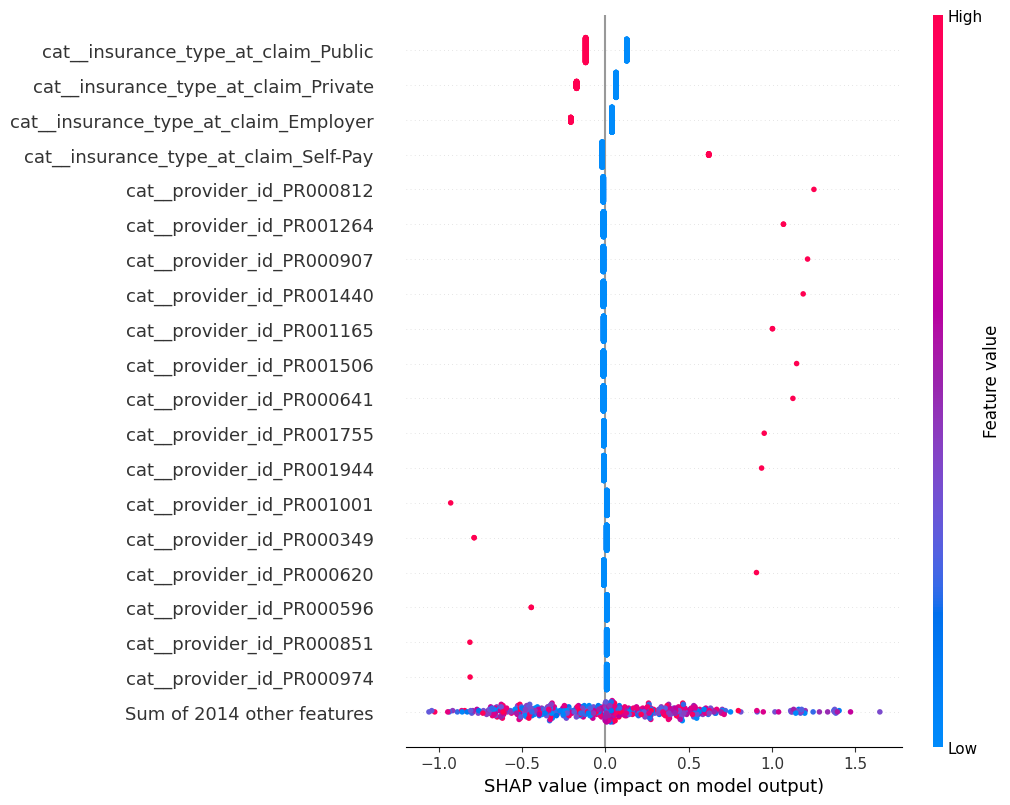

In [27]:
# ============================================================
# 11. SHAP interpretation
# ============================================================

# Transform X using fitted preprocessing
X_transformed = final_model.named_steps["preprocess"].transform(X)

feature_names = final_model.named_steps["preprocess"].get_feature_names_out()

# Convert sparse matrix to dense if needed
if hasattr(X_transformed, "toarray"):
    X_transformed = X_transformed.toarray()

X_shap = pd.DataFrame(X_transformed, columns=feature_names)

# Use a sample for speed
shap_sample = X_shap.sample(
    n=min(500, len(X_shap)),
    random_state=42
)

model_only = final_model.named_steps["model"]

explainer = shap.Explainer(model_only, shap_sample)
shap_values = explainer(shap_sample)

shap.plots.beeswarm(shap_values, max_display=20)


In [28]:
# ============================================================
# 12. Save model outputs
# ============================================================

summary.to_csv("model_performance_nested_cv.csv")
results_df.to_csv("model_performance_by_fold.csv", index=False)

df.to_csv("claims_with_predicted_risk.csv", index=False)

print("Saved:")
print("- model_performance_nested_cv.csv")
print("- model_performance_by_fold.csv")
print("- claims_with_predicted_risk.csv")

Saved:
- model_performance_nested_cv.csv
- model_performance_by_fold.csv
- claims_with_predicted_risk.csv


In [29]:
# ============================================================
# 13. Export model + feature schema for the web app
# ============================================================
# Add this cell to the END of your notebook (model.ipynb), after
# section 10 ("Risk score function B") has run, so that `final_model`,
# `X`, `numeric_features`, `categorical_features`, `low_cutoff` and
# `high_cutoff` all exist in memory.
#
# It writes two files that the Flask app reads at startup:
#   - model.pkl            the fitted sklearn Pipeline (preprocessing + model)
#   - feature_schema.json  the input fields the GUI needs to render,
#                           plus the risk cutoffs, so the app never has
#                           to guess at your data.

import joblib
import json

# --- 1. Save the fitted pipeline -----------------------------------------
joblib.dump(final_model, "model.pkl")

# --- 2. Build a schema describing every input field -----------------------
feature_schema = {"numeric": {}, "categorical": {}}

for col in numeric_features:
    col_data = X[col].dropna()
    feature_schema["numeric"][col] = {
        "min": float(col_data.min()) if len(col_data) else None,
        "max": float(col_data.max()) if len(col_data) else None,
        "mean": round(float(col_data.mean()), 2) if len(col_data) else None,
    }

for col in categorical_features:
    options = sorted(str(v) for v in X[col].dropna().unique().tolist())
    feature_schema["categorical"][col] = options

# --- 3. Save the risk cutoffs so the app matches the notebook exactly -----
risk_cutoffs = {
    "low_cutoff": float(low_cutoff),
    "high_cutoff": float(high_cutoff),
}

schema_out = {
    "model_name": best_model_name,
    "features": feature_schema,
    "risk_cutoffs": risk_cutoffs,
}

with open("feature_schema.json", "w") as f:
    json.dump(schema_out, f, indent=2)

print("Saved model.pkl and feature_schema.json")
print(f"Numeric features ({len(numeric_features)}):", numeric_features)
print(f"Categorical features ({len(categorical_features)}):", categorical_features)


Saved model.pkl and feature_schema.json
Numeric features (7): ['claim_amount', 'wait_days', 'age_at_claim', 'appointment_month', 'appointment_dayofweek', 'submission_month', 'submission_dayofweek']
Categorical features (7): ['insurance_type_at_claim', 'provider_id', 'visit_type', 'gender', 'region', 'chronic_diabetes', 'chronic_hypertension']
